In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, f_oneway

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from scipy.optimize import linprog

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("student_transport_demand_dataset.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 500
Number of columns: 17


In [3]:
df.head()

,Date,Day,Route,Area,Peak_Period,Weather,Student_Demand,Bus_Capacity,Occupancy_Rate,Travel_Distance_KM,Travel_Time_Min,Delay_Min,Fare_Per_Student,Revenue,Operating_Cost,Profit,Satisfaction_Score
0,2025-01-01,Thursday,Route_G,Market Area,Peak,Clear,62,60,100.0,13.74,59.3,19.6,36.74,2204.40,200.88,2003.52,2.4
1,2025-01-01,Thursday,Route_D,Central Area,Peak,Clear,44,50,88.0,7.54,17.0,1.9,30.16,1327.04,129.71,1197.33,3.7
2,2025-01-01,Tuesday,Route_E,Central Area,Off-Peak,Clear,59,50,100.0,8.52,22.7,0.0,35.40,1770.00,161.90,1608.10,4.5
3,2025-01-02,Friday,Route_G,Residential Area,Off-Peak,Clear,52,70,74.3,4.01,9.8,0.0,21.09,1096.68,79.46,1017.22,5.0
4,2025-01-02,Thursday,Route_C,Market Area,Off-Peak,Clear,38,60,63.3,4.74,13.9,6.2,37.37,1420.06,113.75,1306.31,4.9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                500 non-null    str    
 1   Day                 500 non-null    str    
 2   Route               500 non-null    str    
 3   Area                500 non-null    str    
 4   Peak_Period         500 non-null    str    
 5   Weather             500 non-null    str    
 6   Student_Demand      500 non-null    int64  
 7   Bus_Capacity        500 non-null    int64  
 8   Occupancy_Rate      500 non-null    float64
 9   Travel_Distance_KM  500 non-null    float64
 10  Travel_Time_Min     500 non-null    float64
 11  Delay_Min           500 non-null    float64
 12  Fare_Per_Student    500 non-null    float64
 13  Revenue             500 non-null    float64
 14  Operating_Cost      500 non-null    float64
 15  Profit              500 non-null    float64
 16  Satisfaction_Score 

In [5]:
print("Columns in dataset:")

for column in df.columns:
    print(column)

Columns in dataset:
Date
Day
Route
Area
Peak_Period
Weather
Student_Demand
Bus_Capacity
Occupancy_Rate
Travel_Distance_KM
Travel_Time_Min
Delay_Min
Fare_Per_Student
Revenue
Operating_Cost
Profit
Satisfaction_Score


In [6]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
Date                  0
Day                   0
Route                 0
Area                  0
Peak_Period           0
Weather               0
Student_Demand        0
Bus_Capacity          0
Occupancy_Rate        0
Travel_Distance_KM    0
Travel_Time_Min       0
Delay_Min             0
Fare_Per_Student      0
Revenue               0
Operating_Cost        0
Profit                0
Satisfaction_Score    0
dtype: int64


In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [8]:
df.describe()

,Student_Demand,Bus_Capacity,Occupancy_Rate,Travel_Distance_KM,Travel_Time_Min,Delay_Min,Fare_Per_Student,Revenue,Operating_Cost,Profit,Satisfaction_Score
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,55.138000,49.600000,90.720600,9.78548,31.480800,5.538800,30.279900,1331.747160,156.712780,1175.034380,3.821400
std,15.120324,12.005343,15.921627,4.67746,16.514982,5.762888,8.512143,490.432361,46.791449,489.344658,0.766248
min,18.000000,30.000000,30.000000,2.00000,8.000000,0.000000,15.040000,303.300000,62.620000,103.340000,1.500000
25%,44.000000,40.000000,86.000000,5.62750,16.975000,0.000000,23.035000,947.990000,122.405000,816.402500,3.300000
50%,55.000000,50.000000,100.000000,9.66500,30.150000,4.000000,30.420000,1276.870000,156.535000,1120.165000,3.900000
75%,67.000000,60.000000,100.000000,13.76000,42.925000,9.425000,36.900000,1665.590000,189.457500,1504.350000,4.400000
max,90.000000,70.000000,100.000000,17.95000,76.800000,27.400000,45.000000,3150.000000,281.290000,2980.400000,5.000000


In [9]:
route_demand = df.groupby("Route")["Student_Demand"].mean()

print("Average Student Demand by Route:")
print(route_demand.round(2))

Average Student Demand by Route:
Route
Route_A    56.44
Route_B    56.02
Route_C    55.16
Route_D    53.46
Route_E    56.20
Route_F    55.15
Route_G    55.02
Route_H    54.39
Name: Student_Demand, dtype: float64


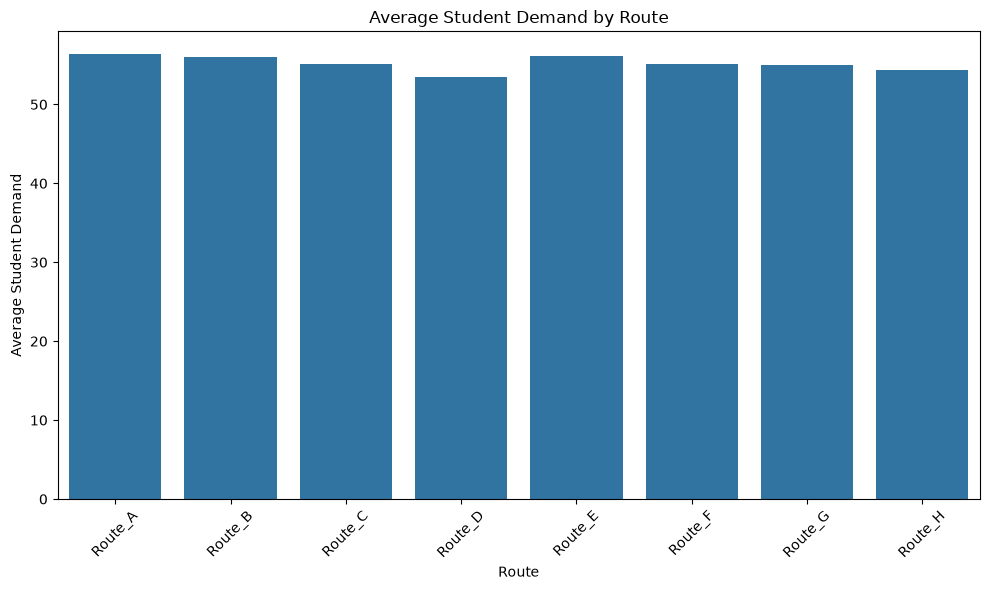

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=route_demand.index,
    y=route_demand.values
)

plt.title("Average Student Demand by Route")
plt.xlabel("Route")
plt.ylabel("Average Student Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
period_demand = df.groupby(
    "Peak_Period"
)["Student_Demand"].mean()

print(period_demand.round(2))

Peak_Period
Off-Peak    46.84
Peak        60.67
Name: Student_Demand, dtype: float64


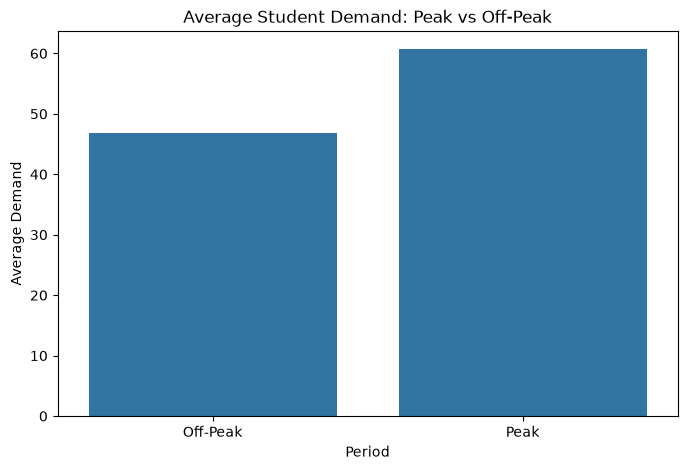

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=period_demand.index,
    y=period_demand.values
)

plt.title("Average Student Demand: Peak vs Off-Peak")
plt.xlabel("Period")
plt.ylabel("Average Demand")

plt.show()

In [13]:
demand = df["Student_Demand"]

print("Mean:", round(demand.mean(), 2))
print("Median:", demand.median())
print("Mode:", demand.mode()[0])
print("Variance:", round(demand.var(), 2))
print("Standard Deviation:", round(demand.std(), 2))
print("Minimum:", demand.min())
print("Maximum:", demand.max())

Mean: 55.14
Median: 55.0
Mode: 70
Variance: 228.62
Standard Deviation: 15.12
Minimum: 18
Maximum: 90


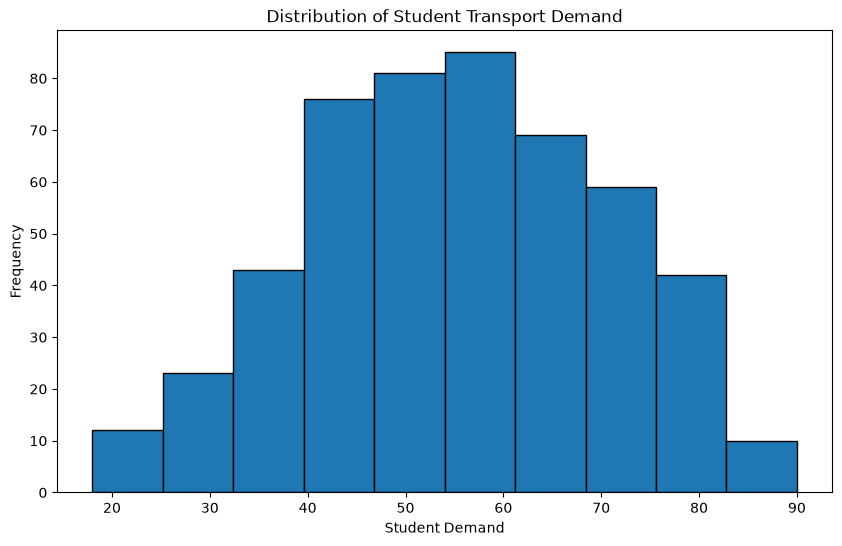

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Student_Demand"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Student Transport Demand")
plt.xlabel("Student Demand")
plt.ylabel("Frequency")

plt.show()

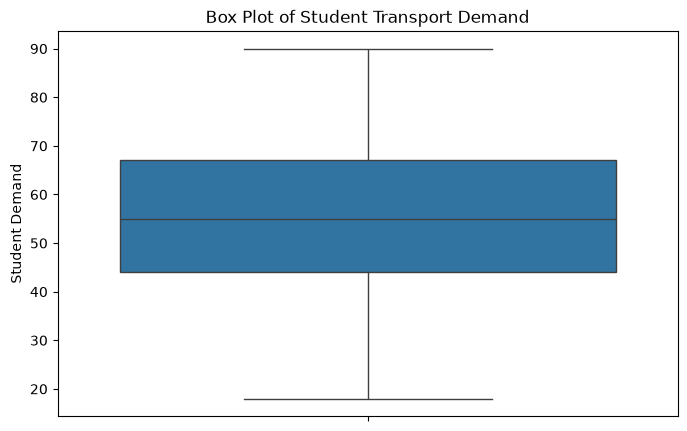

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    y=df["Student_Demand"]
)

plt.title("Box Plot of Student Transport Demand")
plt.ylabel("Student Demand")

plt.show()

In [16]:
numeric_columns = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_columns.corr()

correlation_matrix.round(2)

,Student_Demand,Bus_Capacity,Occupancy_Rate,Travel_Distance_KM,Travel_Time_Min,Delay_Min,Fare_Per_Student,Revenue,Operating_Cost,Profit,Satisfaction_Score
Student_Demand,1.00,0.00,0.70,0.04,0.03,0.03,-0.05,0.35,0.02,0.35,-0.35
Bus_Capacity,0.00,1.00,-0.46,0.05,0.04,0.04,-0.07,0.36,-0.01,0.36,0.18
Occupancy_Rate,0.70,-0.46,1.00,0.04,0.03,-0.02,0.03,0.28,0.06,0.28,-0.25
Travel_Distance_KM,0.04,0.05,0.04,1.00,0.91,0.26,0.04,0.08,0.88,-0.00,-0.62
Travel_Time_Min,0.03,0.04,0.03,0.91,1.00,0.58,0.02,0.05,0.79,-0.02,-0.68
Delay_Min,0.03,0.04,-0.02,0.26,0.58,1.00,-0.03,-0.03,0.20,-0.05,-0.40
Fare_Per_Student,-0.05,-0.07,0.03,0.04,0.02,-0.03,1.00,0.73,0.06,0.72,-0.01
Revenue,0.35,0.36,0.28,0.08,0.05,-0.03,0.73,1.00,0.07,1.00,-0.01
Operating_Cost,0.02,-0.01,0.06,0.88,0.79,0.20,0.06,0.07,1.00,-0.02,-0.56
Profit,0.35,0.36,0.28,-0.00,-0.02,-0.05,0.72,1.00,-0.02,1.00,0.04


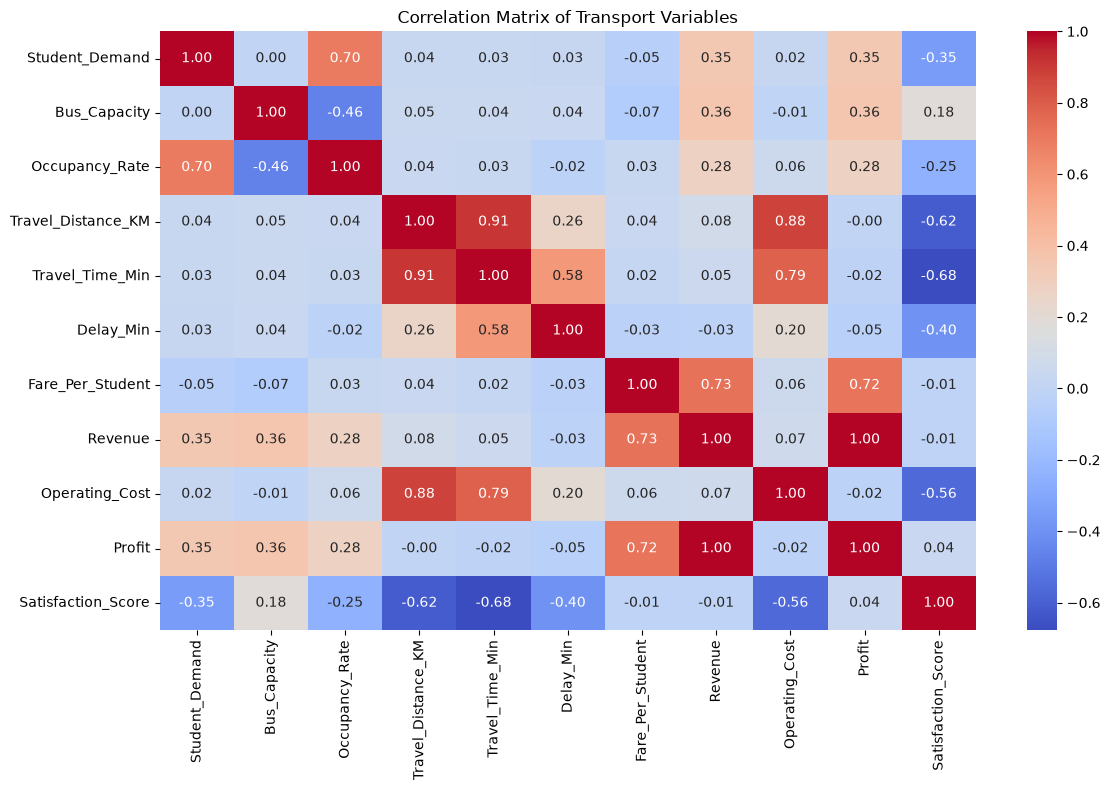

In [17]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Transport Variables")

plt.tight_layout()
plt.show()

In [18]:
X = df[["Travel_Time_Min"]]

y = df["Satisfaction_Score"]

print("Independent Variable:")
print(X.head())

print("\nDependent Variable:")
print(y.head())

Independent Variable:
   Travel_Time_Min
0             59.3
1             17.0
2             22.7
3              9.8
4             13.9

Dependent Variable:
0    2.4
1    3.7
2    4.5
3    5.0
4    4.9
Name: Satisfaction_Score, dtype: float64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 400
Testing records: 100


In [20]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Regression model trained successfully!")

Regression model trained successfully!


In [21]:
y_pred = model.predict(X_test)

print("First 10 predictions:")

print(y_pred[:10])

First 10 predictions:
[3.81601124 4.33160639 3.7697003  3.15839587 3.53814559 3.38377579
 3.70486498 4.38717952 2.80334532 4.14945002]


In [22]:
r2 = r2_score(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

print("Coefficient:", round(model.coef_[0], 4))
print("Intercept:", round(model.intercept_, 4))
print("R² Score:", round(r2, 4))
print("Mean Squared Error:", round(mse, 4))

Coefficient: -0.0309
Intercept: 4.7947
R² Score: 0.4212
Mean Squared Error: 0.3974


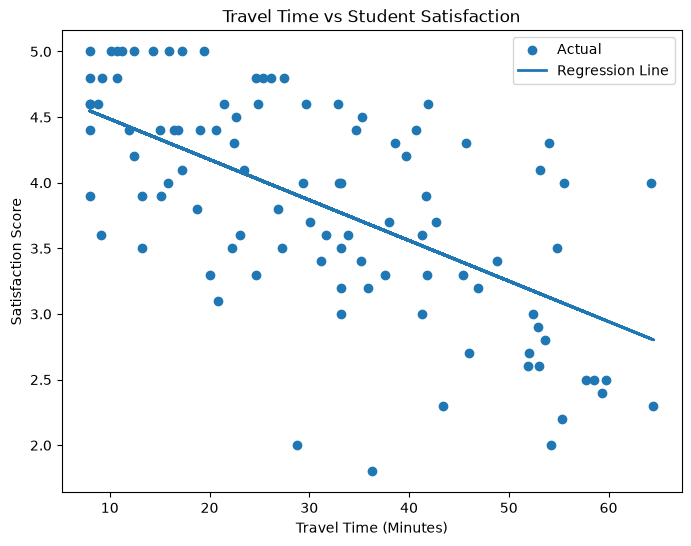

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test,
    y_test,
    label="Actual"
)

plt.plot(
    X_test,
    y_pred,
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Travel Time (Minutes)")
plt.ylabel("Satisfaction Score")

plt.title(
    "Travel Time vs Student Satisfaction"
)

plt.legend()

plt.show()

In [24]:
high_demand_probability = (
    df["Student_Demand"] > 60
).mean()

print(
    "Probability of demand > 60:",
    round(high_demand_probability, 3)
)

Probability of demand > 60: 0.376


In [25]:
peak_probability = (
    df["Peak_Period"] == "Peak"
).mean()

print(
    "Probability of Peak Period:",
    round(peak_probability, 3)
)

Probability of Peak Period: 0.6


In [26]:
rain_probability = (
    df["Weather"] == "Rainy"
).mean()

print(
    "Probability of Rainy Weather:",
    round(rain_probability, 3)
)

Probability of Rainy Weather: 0.124


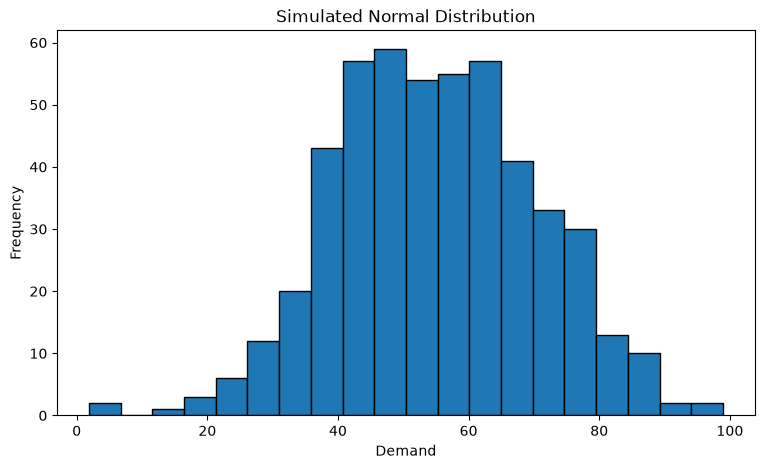

In [27]:
mean_demand = df["Student_Demand"].mean()
std_demand = df["Student_Demand"].std()

normal_data = np.random.normal(
    loc=mean_demand,
    scale=std_demand,
    size=500
)

plt.figure(figsize=(9, 5))

plt.hist(
    normal_data,
    bins=20,
    edgecolor="black"
)

plt.title("Simulated Normal Distribution")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.show()

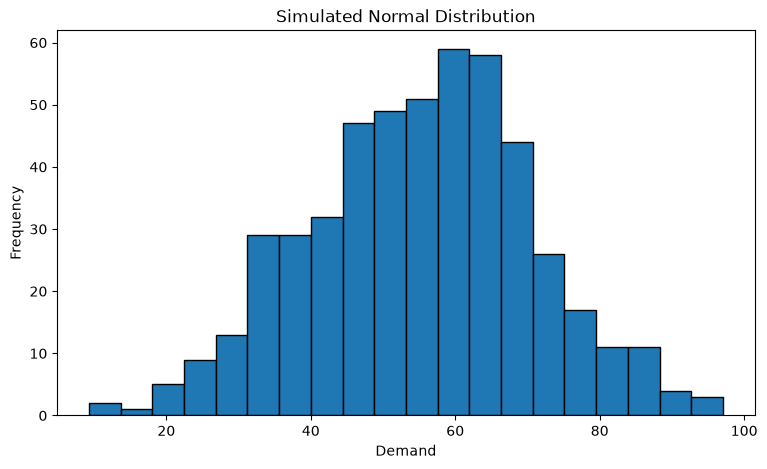

In [28]:
mean_demand = df["Student_Demand"].mean()
std_demand = df["Student_Demand"].std()

normal_data = np.random.normal(
    loc=mean_demand,
    scale=std_demand,
    size=500
)

plt.figure(figsize=(9, 5))

plt.hist(
    normal_data,
    bins=20,
    edgecolor="black"
)

plt.title("Simulated Normal Distribution")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.show()

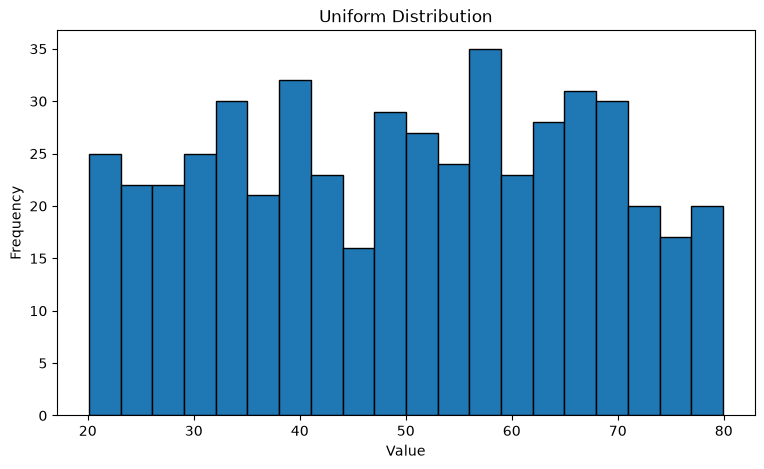

In [29]:
uniform_data = np.random.uniform(
    20,
    80,
    500
)

plt.figure(figsize=(9, 5))

plt.hist(
    uniform_data,
    bins=20,
    edgecolor="black"
)

plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

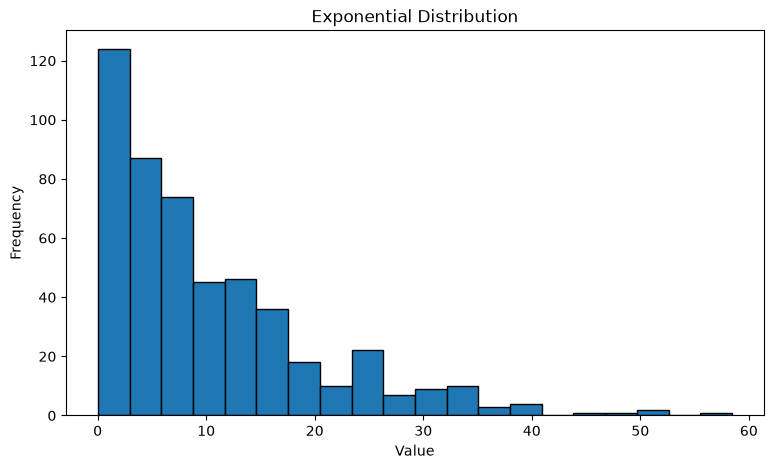

In [30]:
exponential_data = np.random.exponential(
    scale=10,
    size=500
)

plt.figure(figsize=(9, 5))

plt.hist(
    exponential_data,
    bins=20,
    edgecolor="black"
)

plt.title("Exponential Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

In [31]:
probabilities = {
    "Low Demand": 0.30,
    "Medium Demand": 0.40,
    "High Demand": 0.30
}

profits = {
    "40 Seat Bus": [800, 1200, 1300],
    "60 Seat Bus": [700, 1500, 1900],
    "70 Seat Bus": [600, 1400, 2100]
}

expected_values = {}

for bus, profit_values in profits.items():

    expected_value = (
        profit_values[0] * probabilities["Low Demand"]
        + profit_values[1] * probabilities["Medium Demand"]
        + profit_values[2] * probabilities["High Demand"]
    )

    expected_values[bus] = expected_value

    print(
        bus,
        "Expected Value =",
        round(expected_value, 2)
    )

best_option = max(
    expected_values,
    key=expected_values.get
)

print("\nOptimal Bus Option:", best_option)

40 Seat Bus Expected Value = 1110.0
60 Seat Bus Expected Value = 1380.0
70 Seat Bus Expected Value = 1370.0

Optimal Bus Option: 60 Seat Bus


In [32]:
population = df["Student_Demand"]

sample_means = []

for i in range(1000):

    sample = population.sample(
        n=30,
        replace=True
    )

    sample_means.append(
        sample.mean()
    )

print(
    "Population Mean:",
    round(population.mean(), 2)
)

print(
    "Mean of Sample Means:",
    round(np.mean(sample_means), 2)
)

Population Mean: 55.14
Mean of Sample Means: 55.2


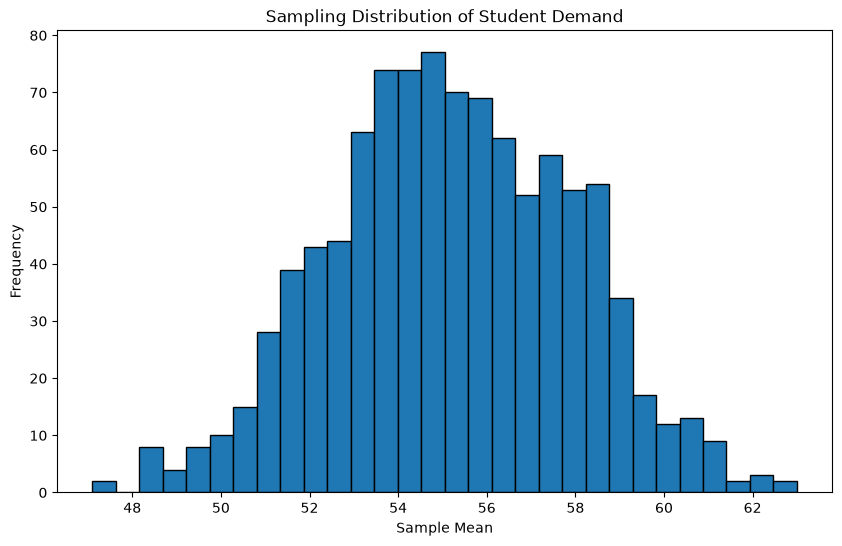

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(
    sample_means,
    bins=30,
    edgecolor="black"
)

plt.title(
    "Sampling Distribution of Student Demand"
)

plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

In [34]:
data = df["Student_Demand"]

sample_mean = data.mean()

standard_error = stats.sem(data)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(data) - 1,
    loc=sample_mean,
    scale=standard_error
)

print("Sample Mean:", round(sample_mean, 2))

print(
    "95% Confidence Interval:"
)

print(
    "(",
    round(confidence_interval[0], 2),
    ",",
    round(confidence_interval[1], 2),
    ")"
)

Sample Mean: 55.14
95% Confidence Interval:
( 53.81 , 56.47 )


In [35]:
peak_demand = df[
    df["Peak_Period"] == "Peak"
]["Student_Demand"]

off_peak_demand = df[
    df["Peak_Period"] == "Off-Peak"
]["Student_Demand"]

t_statistic, p_value = ttest_ind(
    peak_demand,
    off_peak_demand,
    equal_var=False
)

print("T-Statistic:", round(t_statistic, 4))
print("P-Value:", round(p_value, 6))

T-Statistic: 11.1288
P-Value: 0.0


In [36]:
alpha = 0.05

if p_value < alpha:

    print("Reject H0")

    print(
        "Peak and off-peak demand are significantly different."
    )

else:

    print("Fail to Reject H0")

    print(
        "There is no significant difference between "
        "peak and off-peak demand."
    )

Reject H0
Peak and off-peak demand are significantly different.


In [37]:
df["Date"] = pd.to_datetime(
    df["Date"]
)

daily_demand = (
    df.groupby("Date")["Student_Demand"]
    .sum()
)

daily_demand.head()

Date
2025-01-01    165
2025-01-02    124
2025-01-03    138
2025-01-04    182
2025-01-05     99
Name: Student_Demand, dtype: int64

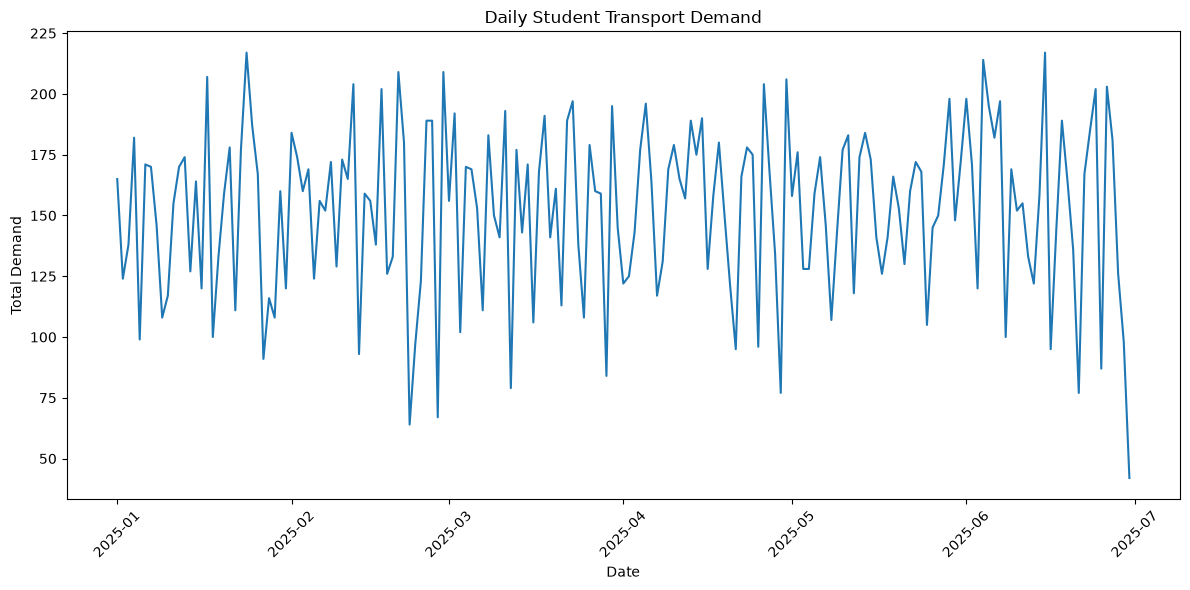

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_demand.index,
    daily_demand.values
)

plt.title(
    "Daily Student Transport Demand"
)

plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [39]:
forecast_model = ExponentialSmoothing(
    daily_demand,
    trend="add",
    seasonal=None
)

forecast_fit = forecast_model.fit()

forecast = forecast_fit.forecast(
    30
)

print("Next 30 Days Forecast:")
print(forecast)

Next 30 Days Forecast:
2025-07-01    154.030024
2025-07-02    154.048872
2025-07-03    154.067719
2025-07-04    154.086566
2025-07-05    154.105414
2025-07-06    154.124261
2025-07-07    154.143108
2025-07-08    154.161956
2025-07-09    154.180803
2025-07-10    154.199650
2025-07-11    154.218498
2025-07-12    154.237345
2025-07-13    154.256193
2025-07-14    154.275040
2025-07-15    154.293887
2025-07-16    154.312735
2025-07-17    154.331582
2025-07-18    154.350429
2025-07-19    154.369277
2025-07-20    154.388124
2025-07-21    154.406971
2025-07-22    154.425819
2025-07-23    154.444666
2025-07-24    154.463513
2025-07-25    154.482361
2025-07-26    154.501208
2025-07-27    154.520055
2025-07-28    154.538903
2025-07-29    154.557750
2025-07-30    154.576597
Freq: D, dtype: float64


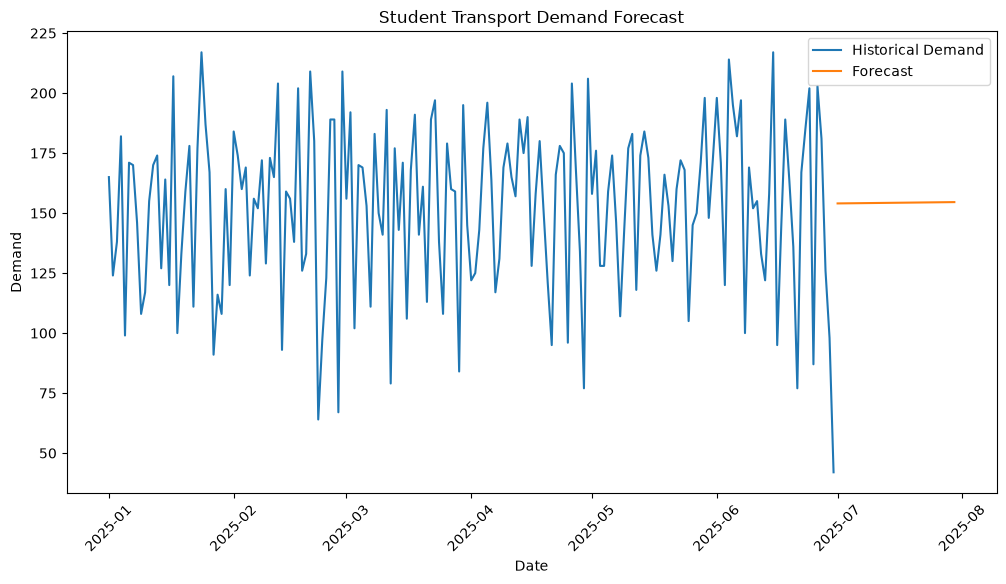

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_demand.index,
    daily_demand.values,
    label="Historical Demand"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast"
)

plt.title(
    "Student Transport Demand Forecast"
)

plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [41]:
route_average_demand = (
    df.groupby("Route")["Student_Demand"]
    .mean()
    .sort_values(ascending=False)
)

print(
    "Average Demand by Route:"
)

print(
    route_average_demand.round(2)
)

Average Demand by Route:
Route
Route_A    56.44
Route_E    56.20
Route_B    56.02
Route_C    55.16
Route_F    55.15
Route_G    55.02
Route_H    54.39
Route_D    53.46
Name: Student_Demand, dtype: float64


In [42]:
bus_capacities = np.array([
    30,
    40,
    50,
    60,
    70
])

bus_costs = np.array([
    300,
    380,
    450,
    520,
    600
])

maximum_demand = route_average_demand.max()

print(
    "Maximum Average Demand:",
    round(maximum_demand, 2)
)

Maximum Average Demand: 56.44


In [43]:
A_ub = -bus_capacities.reshape(1, -1)

b_ub = np.array([
    -maximum_demand
])

result = linprog(
    c=bus_costs,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=[(0, 1)] * len(bus_capacities),
    method="highs"
)

if result.success:

    selected_index = np.argmax(
        result.x
    )

    selected_capacity = bus_capacities[
        selected_index
    ]

    selected_cost = bus_costs[
        selected_index
    ]

    print(
        "Recommended Bus Capacity:",
        selected_capacity,
        "seats"
    )

    print(
        "Estimated Cost:",
        selected_cost
    )

else:

    print(
        "Optimization failed."
    )

Recommended Bus Capacity: 70 seats
Estimated Cost: 600


In [44]:
np.random.seed(42)

demand_values = df[
    "Student_Demand"
].values

simulation_means = []

for i in range(1000):

    simulated_sample = np.random.choice(
        demand_values,
        size=len(demand_values),
        replace=True
    )

    simulation_means.append(
        simulated_sample.mean()
    )

print(
    "Simulation Mean:",
    round(np.mean(simulation_means), 2)
)

print(
    "Simulation Minimum:",
    round(np.min(simulation_means), 2)
)

print(
    "Simulation Maximum:",
    round(np.max(simulation_means), 2)
)

print(
    "Simulation Standard Deviation:",
    round(np.std(simulation_means), 2)
)

Simulation Mean: 55.14
Simulation Minimum: 52.75
Simulation Maximum: 57.28
Simulation Standard Deviation: 0.69


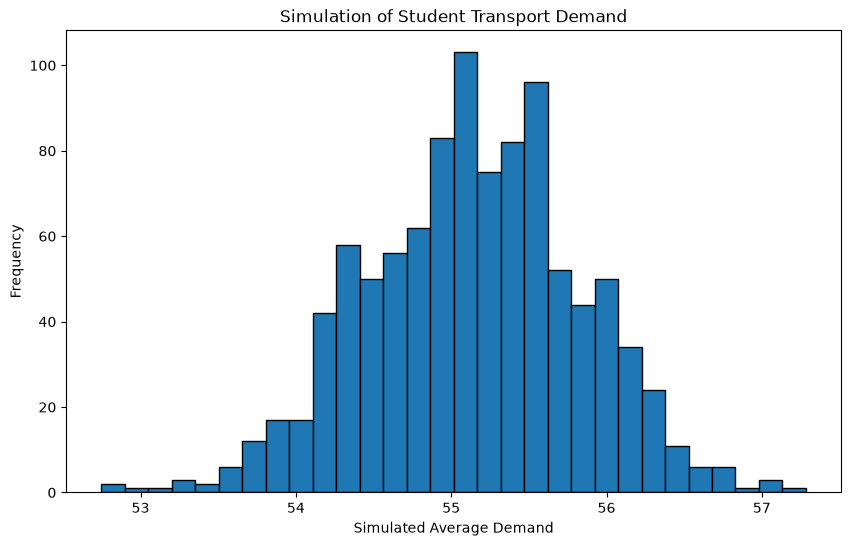

In [45]:
plt.figure(figsize=(10, 6))

plt.hist(
    simulation_means,
    bins=30,
    edgecolor="black"
)

plt.title(
    "Simulation of Student Transport Demand"
)

plt.xlabel("Simulated Average Demand")
plt.ylabel("Frequency")

plt.show()

In [46]:
route_groups = []

for route, group in df.groupby("Route"):

    route_groups.append(
        group["Student_Demand"].values
    )

f_statistic, p_value = f_oneway(
    *route_groups
)

print(
    "F-Statistic:",
    round(f_statistic, 4)
)

print(
    "P-Value:",
    round(p_value, 6)
)

F-Statistic: 0.2894
P-Value: 0.958035


In [47]:
alpha = 0.05

if p_value < alpha:

    print(
        "Reject H0"
    )

    print(
        "Student demand differs significantly among routes."
    )

else:

    print(
        "Fail to Reject H0"
    )

    print(
        "No significant difference was found among routes."
    )

Fail to Reject H0
No significant difference was found among routes.
